# BREADS MIRI Tutorial 1: MIRI Data Reductions for BREADS IFU high contrast


This notebook demonstrates how to reduce MIRI MRS data, starting from uncal files, to produce the custom/optimized cal files that will be used for forward modeling. 

<div class="alert alert-block alert-info">
This is the first in a series of notebooks demonstrating data reduction for MIRI using BREADS. 
    <OL><LI>Tutorial 1 (This notebook): Pipeline data reductions to get ready for forward modeling</LI>
        <LI>Tutorial 2: Forward modeling and measuring SNR of a companion</LI>
        <LI>Tutorial 3: Generating data-cube-like representations of the forward modeled data. </LI>
</div>


## Introduction

This makes use of the JWST pipeline (invoked via utility functions in BREADS) and custom code within BREADS, particularly for fitting and handling the fringe patterns in the MRS.

To forward model JWST/MIRI data with breads we want to: 
 1. Reduce the raw `uncal` FITS files to calibrated `cal` FITS files, using the JWST pipeline with a handful of small customizations.
 2. A larger customization is some code for dealing with the fringing within MRS. Breads has some functions to estimate and calibrate the fringing in science data. To do this it needs a calibration dataset observed similarly to the science data. If a PSF calibrator has been observed, it will work well for this.


### Getting an Example dataset for this tutorial: GQ Lup B
We will demonstrate this with a reduction of the data on GQ Lup B from JWST program 1640 observation 9; we'll use observation 10 from that program as the fringe calibrator. 

You can download these data using the [jwst_mast_query](https://github.com/spacetelescope/jwst_mast_query) package, using this command line: 

```
jwst_download.py -i miri  --propID 1294 --obsnums 3 4 -f uncal --sca mirifushort  -d 2023-01-10 2023-01-12 --skip_propID2outsubdir
```

This tutorial assumes you have the resulting files (24 of them: 2 targets × 3 MRS sub-bands × 4 dithers; total of 9 GB) and they have been placed in a subdirectory `data` under this current working directory.  For instance you can do: 

```
mkdir data
cd data
jwst_download.py -i miri  --propID 1294 --obsnums 3 4 -f uncal --sca mirifushort  -d 2023-01-10 2023-01-12 --skip_propID2outsubdir

```

## Set Paths and Parameters

In [1]:
# Root directory for where the data files are, including the uncal input files
# and the output files will be in subdirectories created under here. 
data_dir = "./data" 

# Which target is which? 
#   These must match the target names as defined in APT and written in FITS header keywords for TARGNAME
science_target_name = "* bet Pic"
flat_reference_target_name = "* N Car"

In [2]:
# The need for this will eventually be removed
import os

# We need to tell BREADS where to store reduced fringe flat files. This can be shared among multiple programs.
# In this case let's just use a subdirectory here, which suffices for this tutorial.

os.environ['FLAT_PATH'] = './miri_fringe_flats'
os.makedirs(os.environ['FLAT_PATH'], exist_ok=True)


## Which MRS bands to reduce? 

You can select just a subset of the data to reduce, to get shorter runtimes.  If particular spectral ranges are of interest just select those bands. 

The syntax here is like `'12A'` for bands 1A and 2A (observed simultaneously on the short wave detector), `'12B'`, `'34A'`, etc. 

In [3]:
list_bands = ['12A']

## Stage 1 reductions

### Imports

In [4]:
import os, glob
from breads.jwst_tools.reduction_utils import run_stage1_miri, run_stage2_miri, run_stage3_miri, flat_fringing_stage1
from breads.jwst_tools.flat_miri_utils import run_miri_flat_running_mean

/Users/mperrin/miniconda3/envs/stenv-py3.12-2025.07.16/lib/python3.12/site-packages/stsci/__init__.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__('pkg_resources').declare_namespace(__name__)


### Run the detector1 pipeline

This runs the jwst pipeline's `calwebb_detector1` pipeline, with some small tweaks. 
- Inputs: finds `uncal.fits` files in the path given by `uncaldir`
- Outputs: writes `rate.fit`s file in new subdirectories organized by `[targetname]/[MRS band]`

This will take a while to run (many minutes), but only needs to be run once. 

In [5]:
rate_files, targnames = run_stage1_miri(data_dir, 
                                        overwrite=False,           # If output files already exist, no need to re-compute them.
                                        maximum_cores="all",       # This is passed to pipeline's jump and ramp_fit steps. 
                                        skip_dark=False,           # Sometimes master background sub is preferable to master dark sub, for some datasets. 
                                       )

Searching in ./data for files matching jw*_uncal.fits
	Found 8 input files to process
	jw01294003001_03102_00001_mirifushort_uncal.fits
	jw01294003001_03102_00002_mirifushort_uncal.fits
	jw01294003001_03102_00003_mirifushort_uncal.fits
	jw01294003001_03102_00004_mirifushort_uncal.fits
	jw01294004001_03102_00001_mirifushort_uncal.fits
	jw01294004001_03102_00002_mirifushort_uncal.fits
	jw01294004001_03102_00003_mirifushort_uncal.fits
	jw01294004001_03102_00004_mirifushort_uncal.fits
DEBUG target_names ['* bet Pic', '* N Car']
48657.247317708
DEBUG target_name * bet Pic
Processing file 1 of 4.


2025-11-12 13:17:26,610 - CRDS - INFO -  Calibration SW Found: jwst 1.20.2 (/Users/mperrin/miniconda3/envs/stenv-py3.12-2025.07.16/lib/python3.12/site-packages/jwst-1.20.2.dist-info)
2025-11-12 13:17:27,576 - stpipe.step - INFO - PARS-EMICORRSTEP parameters found: /Users/mperrin/data/crds_cache/references/jwst/miri/jwst_miri_pars-emicorrstep_0003.asdf
2025-11-12 13:17:27,589 - stpipe.step - INFO - PARS-DARKCURRENTSTEP parameters found: /Users/mperrin/data/crds_cache/references/jwst/miri/jwst_miri_pars-darkcurrentstep_0001.asdf
2025-11-12 13:17:27,597 - stpipe.step - INFO - PARS-JUMPSTEP parameters found: /Users/mperrin/data/crds_cache/references/jwst/miri/jwst_miri_pars-jumpstep_0007.asdf
2025-11-12 13:17:27,605 - stpipe.pipeline - INFO - PARS-DETECTOR1PIPELINE parameters found: /Users/mperrin/data/crds_cache/references/jwst/miri/jwst_miri_pars-detector1pipeline_0010.asdf
2025-11-12 13:17:27,616 - stpipe.step - INFO - Detector1Pipeline instance created.
2025-11-12 13:17:27,617 - stpipe

Processing file 2 of 4.


2025-11-12 13:17:46,849 - stpipe.pipeline - INFO - Prefetching reference files for dataset: 'jw01294003001_03102_00002_mirifushort_uncal.fits' reftypes = ['dark', 'emicorr', 'gain', 'linearity', 'mask', 'readnoise', 'reset', 'rscd', 'saturation', 'superbias']
2025-11-12 13:17:46,851 - stpipe.pipeline - INFO - Prefetch for DARK reference file is '/Users/mperrin/data/crds_cache/references/jwst/miri/jwst_miri_dark_0112.fits'.
2025-11-12 13:17:46,852 - stpipe.pipeline - INFO - Prefetch for EMICORR reference file is '/Users/mperrin/data/crds_cache/references/jwst/miri/jwst_miri_emicorr_0003.asdf'.
2025-11-12 13:17:46,852 - stpipe.pipeline - INFO - Prefetch for GAIN reference file is '/Users/mperrin/data/crds_cache/references/jwst/miri/jwst_miri_gain_0054.fits'.
2025-11-12 13:17:46,853 - stpipe.pipeline - INFO - Prefetch for LINEARITY reference file is '/Users/mperrin/data/crds_cache/references/jwst/miri/jwst_miri_linearity_0030.fits'.
2025-11-12 13:17:46,853 - stpipe.pipeline - INFO - Prefe

Processing file 3 of 4.


...

2025-11-12 13:19:50,220 - stpipe.pipeline - INFO - Prefetch for GAIN reference file is '/Users/mperrin/data/crds_cache/references/jwst/miri/jwst_miri_gain_0054.fits'.
2025-11-12 13:19:50,220 - stpipe.pipeline - INFO - Prefetch for LINEARITY reference file is '/Users/mperrin/data/crds_cache/references/jwst/miri/jwst_miri_linearity_0030.fits'.
2025-11-12 13:19:50,221 - stpipe.pipeline - INFO - Prefetch for MASK reference file is '/Users/mperrin/data/crds_cache/references/jwst/miri/jwst_miri_mask_0046.fits'.
2025-11-12 13:19:50,221 - stpipe.pipeline - INFO - Prefetch for READNOISE reference file is '/Users/mperrin/data/crds_cache/references/jwst/miri/jwst_miri_readnoise_0087.fits'.
2025-11-12 13:19:50,222 - stpipe.pipeline - INFO - Prefetch for RESET reference file is '/Users/mperrin/data/crds_cache/references/jwst/miri/jwst_miri_reset_0078.fits'.
2025-11-12 13:19:50,222 - stpipe.pipeline - INFO - Prefetch for RSCD reference file is '/Users/mperrin/data/crds_cache/references/jwst/miri/jws

Processing file 4 of 4.


2025-11-12 13:20:22,303 - stpipe.pipeline - INFO - Prefetching reference files for dataset: 'jw01294004001_03102_00004_mirifushort_uncal.fits' reftypes = ['dark', 'emicorr', 'gain', 'linearity', 'mask', 'readnoise', 'reset', 'rscd', 'saturation', 'superbias']
2025-11-12 13:20:22,306 - stpipe.pipeline - INFO - Prefetch for DARK reference file is '/Users/mperrin/data/crds_cache/references/jwst/miri/jwst_miri_dark_0112.fits'.
2025-11-12 13:20:22,307 - stpipe.pipeline - INFO - Prefetch for EMICORR reference file is '/Users/mperrin/data/crds_cache/references/jwst/miri/jwst_miri_emicorr_0003.asdf'.
2025-11-12 13:20:22,307 - stpipe.pipeline - INFO - Prefetch for GAIN reference file is '/Users/mperrin/data/crds_cache/references/jwst/miri/jwst_miri_gain_0054.fits'.
2025-11-12 13:20:22,308 - stpipe.pipeline - INFO - Prefetch for LINEARITY reference file is '/Users/mperrin/data/crds_cache/references/jwst/miri/jwst_miri_linearity_0030.fits'.
2025-11-12 13:20:22,308 - stpipe.pipeline - INFO - Prefe

Total Runtime: 208.7108 seconds


/var/folders/wj/p62fp78j0z1b4xyr2yql1prw00042w/T/ipykernel_22998/3892037653.py:1: ResourceWarning: unclosed file <_io.BufferedReader name='./data/jw01294004001_03102_00004_mirifushort_uncal.fits'>
  rate_files, targnames = run_stage1_miri(data_dir,


The output files are going to be in subdirectories organized by target name.  For example files like this: 

In [6]:
glob.glob(os.path.join(data_dir, science_target_name, list_bands[0], "stage1", "*.fits"))

['./data/* bet Pic/12A/stage1/jw01294003001_03102_00002_mirifushort_rate.fits',
 './data/* bet Pic/12A/stage1/jw01294003001_03102_00002_mirifushort_rateints.fits',
 './data/* bet Pic/12A/stage1/jw01294003001_03102_00004_mirifushort_rate.fits',
 './data/* bet Pic/12A/stage1/jw01294003001_03102_00003_mirifushort_rateints.fits',
 './data/* bet Pic/12A/stage1/jw01294003001_03102_00003_mirifushort_rate.fits',
 './data/* bet Pic/12A/stage1/jw01294003001_03102_00001_mirifushort_rate.fits',
 './data/* bet Pic/12A/stage1/jw01294003001_03102_00004_mirifushort_rateints.fits',
 './data/* bet Pic/12A/stage1/jw01294003001_03102_00001_mirifushort_rateints.fits']

### Handle the MIRI MRS fringing

These are extra steps, custom to breads, for dealing with fringing.

The function `run_miri_flat_running_mean` wil take the rate files of the reference star target and compute a running mean column-wise to estimate the continuum in between the fringes. Then the column is divided by this continuum to get only the fringes. These flats are stored in the miri_flat folder.


In [7]:
# Here we pass in the target name for the second target, which in this case is the reference star. 

run_miri_flat_running_mean(data_dir, 
                           flat_reference_target_name, 
                           output_dir=None, 
                           list_bands=list_bands, 
                           overwrite=True             # If output files already exist, no need to re-compute them.
                          )

Computing flat for band 12A
[DEBUG] Writing flat image to ./miri_fringe_flats/12A
Computing running mean flat for jw01294004001_03102_00002_mirifushort_rate.fits
==> Estimated fringe flat written to ./miri_fringe_flats/12A/jw01294004001_03102_00002_mirifushort_flat.fits
Computing running mean flat for jw01294004001_03102_00004_mirifushort_rate.fits
==> Estimated fringe flat written to ./miri_fringe_flats/12A/jw01294004001_03102_00004_mirifushort_flat.fits
Computing running mean flat for jw01294004001_03102_00003_mirifushort_rate.fits
==> Estimated fringe flat written to ./miri_fringe_flats/12A/jw01294004001_03102_00003_mirifushort_flat.fits
Computing running mean flat for jw01294004001_03102_00001_mirifushort_rate.fits
==> Estimated fringe flat written to ./miri_fringe_flats/12A/jw01294004001_03102_00001_mirifushort_flat.fits


In [8]:
flat_fringing_stage1(data_dir, science_target_name, list_bands=list_bands, flat_path=None, flat_extended=True, overwrite=True)

48867.785647166
Searching in ./data/* bet Pic/12A/stage1 for files matching jw*_rate.fits
	Found 4 input files to process
	jw01294003001_03102_00001_mirifushort_rate.fits
	jw01294003001_03102_00002_mirifushort_rate.fits
	jw01294003001_03102_00003_mirifushort_rate.fits
	jw01294003001_03102_00004_mirifushort_rate.fits
0 ./data/* bet Pic/12A/stage1/jw01294003001_03102_00001_mirifushort_rate.fits
Searching fringes flat files in: ./miri_fringe_flats
Band: SHORT
Brightest column for Channel CH2: 578
jw01294004001_03102_00001_mirifushort_flat.fits 11.83430662363583
Flat selected: jw01294004001_03102_00001_mirifushort_flat.fits
==> Plot saved to ./fig_fringes_jw01294003001_03102_00001_mirifushort_rate.png


/Users/mperrin/Dropbox (Personal)/Documents/software/git/breads/breads/jwst_tools/reduction_utils.py:1530: ResourceWarning: unclosed file <_io.BufferedReader name='./data/* bet Pic/12A/stage1/jw01294003001_03102_00001_mirifushort_rate.fits'>
  best_flat, flat_name, std_min = best_flat_selection(rate_file, flat_path_rate, channel,
/Users/mperrin/Dropbox (Personal)/Documents/software/git/breads/breads/jwst_tools/reduction_utils.py:1530: ResourceWarning: unclosed file <_io.BufferedReader name='./miri_fringe_flats/12A/jw01294004001_03102_00001_mirifushort_flat.fits'>
  best_flat, flat_name, std_min = best_flat_selection(rate_file, flat_path_rate, channel,
/Users/mperrin/Dropbox (Personal)/Documents/software/git/breads/breads/jwst_tools/reduction_utils.py:1538: RuntimeWarning: invalid value encountered in divide
  hdu_copy['ERR'].data /= best_flat


==> Wrote fringe-corrected file to ./data/* bet Pic/12A/stage1_flat/jw01294003001_03102_00001_mirifushort_rate.fits
1 ./data/* bet Pic/12A/stage1/jw01294003001_03102_00002_mirifushort_rate.fits
Searching fringes flat files in: ./miri_fringe_flats
Band: SHORT
Brightest column for Channel CH2: 826
jw01294004001_03102_00002_mirifushort_flat.fits 6.021316704790502
Flat selected: jw01294004001_03102_00002_mirifushort_flat.fits
==> Plot saved to ./fig_fringes_jw01294003001_03102_00002_mirifushort_rate.png
==> Wrote fringe-corrected file to ./data/* bet Pic/12A/stage1_flat/jw01294003001_03102_00002_mirifushort_rate.fits
2 ./data/* bet Pic/12A/stage1/jw01294003001_03102_00003_mirifushort_rate.fits


/Users/mperrin/Dropbox (Personal)/Documents/software/git/breads/breads/jwst_tools/reduction_utils.py:1530: ResourceWarning: unclosed file <_io.BufferedReader name='./data/* bet Pic/12A/stage1/jw01294003001_03102_00002_mirifushort_rate.fits'>
  best_flat, flat_name, std_min = best_flat_selection(rate_file, flat_path_rate, channel,
/Users/mperrin/Dropbox (Personal)/Documents/software/git/breads/breads/jwst_tools/reduction_utils.py:1530: ResourceWarning: unclosed file <_io.BufferedReader name='./miri_fringe_flats/12A/jw01294004001_03102_00002_mirifushort_flat.fits'>
  best_flat, flat_name, std_min = best_flat_selection(rate_file, flat_path_rate, channel,
/Users/mperrin/Dropbox (Personal)/Documents/software/git/breads/breads/jwst_tools/reduction_utils.py:1530: ResourceWarning: unclosed file <_io.BufferedReader name='./data/* bet Pic/12A/stage1/jw01294003001_03102_00003_mirifushort_rate.fits'>
  best_flat, flat_name, std_min = best_flat_selection(rate_file, flat_path_rate, channel,
/Users/m

Searching fringes flat files in: ./miri_fringe_flats
Band: SHORT
Brightest column for Channel CH2: 994
jw01294004001_03102_00003_mirifushort_flat.fits 11.753547556496155
Flat selected: jw01294004001_03102_00003_mirifushort_flat.fits
==> Plot saved to ./fig_fringes_jw01294003001_03102_00003_mirifushort_rate.png
==> Wrote fringe-corrected file to ./data/* bet Pic/12A/stage1_flat/jw01294003001_03102_00003_mirifushort_rate.fits
3 ./data/* bet Pic/12A/stage1/jw01294003001_03102_00004_mirifushort_rate.fits
Searching fringes flat files in: ./miri_fringe_flats
Band: SHORT
Brightest column for Channel CH2: 825
jw01294004001_03102_00004_mirifushort_flat.fits 8.09204589565036
Flat selected: jw01294004001_03102_00004_mirifushort_flat.fits
==> Plot saved to ./fig_fringes_jw01294003001_03102_00004_mirifushort_rate.png
==> Wrote fringe-corrected file to ./data/* bet Pic/12A/stage1_flat/jw01294003001_03102_00004_mirifushort_rate.fits


/Users/mperrin/Dropbox (Personal)/Documents/software/git/breads/breads/jwst_tools/reduction_utils.py:1530: ResourceWarning: unclosed file <_io.BufferedReader name='./data/* bet Pic/12A/stage1/jw01294003001_03102_00004_mirifushort_rate.fits'>
  best_flat, flat_name, std_min = best_flat_selection(rate_file, flat_path_rate, channel,
/Users/mperrin/Dropbox (Personal)/Documents/software/git/breads/breads/jwst_tools/reduction_utils.py:1530: ResourceWarning: unclosed file <_io.BufferedReader name='./miri_fringe_flats/12A/jw01294004001_03102_00004_mirifushort_flat.fits'>
  best_flat, flat_name, std_min = best_flat_selection(rate_file, flat_path_rate, channel,


The fringe flat correction step makes some plots which you can optionally look at. These give a small view of how well the fringing pattern matches between science data and calibrator, for a small spectral region. This is mostly useful if you are trying to use fringe calibrator data from a different program or another time, and want to see how well it is working. If there are multiple fringe flats available in the directory, then the software will automatically select the one that best matches.

In [9]:
!open fig*png

/Users/mperrin/miniconda3/envs/stenv-py3.12-2025.07.16/lib/python3.12/pty.py:95: DeprecationWarning: This process (pid=22998) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()


## Stage 2 reductions

This outputs `cal.fits` files for the selected MRS sub-bands, written into the output subdirectories organized by [targetname]/[MRS band]

In [10]:
## run_stage2
print("Run stage 2")
cal_files = run_stage2_miri(data_dir, science_target_name, 
                            list_bands=list_bands, 
                            custom_flatted=True,         # default is true
                            skip_cubes=True,             # default is true
                            skip_fringe=True,            # default is false
                            skip_residual_fringes=True,  # default is false
                            skip_flatfield=True,         # default is false
                            skip_straylight=True,        # default is true
                            overwrite=False)


Run stage 2
48868.88941425
Processing the custom flatted rate files in ./data/* bet Pic/12A/stage1_flat for stage 2.
Searching in ./data/* bet Pic/12A/stage1_flat for files matching jw*_rate.fits
	Found 4 input files to process
	jw01294003001_03102_00001_mirifushort_rate.fits
	jw01294003001_03102_00002_mirifushort_rate.fits
	jw01294003001_03102_00003_mirifushort_rate.fits
	jw01294003001_03102_00004_mirifushort_rate.fits
0 ./data/* bet Pic/12A/stage1_flat/jw01294003001_03102_00001_mirifushort_rate.fits


2025-11-12 13:20:57,732 - stpipe.step - INFO - PARS-RESAMPLESPECSTEP parameters found: /Users/mperrin/data/crds_cache/references/jwst/miri/jwst_miri_pars-resamplespecstep_0001.asdf
2025-11-12 13:20:57,739 - stpipe.step - INFO - PARS-EXTRACT1DSTEP parameters found: /Users/mperrin/data/crds_cache/references/jwst/miri/jwst_miri_pars-extract1dstep_0001.asdf
2025-11-12 13:20:57,749 - stpipe.step - INFO - PARS-RESAMPLESPECSTEP parameters found: /Users/mperrin/data/crds_cache/references/jwst/miri/jwst_miri_pars-resamplespecstep_0001.asdf
2025-11-12 13:20:57,757 - stpipe.step - INFO - PARS-EXTRACT1DSTEP parameters found: /Users/mperrin/data/crds_cache/references/jwst/miri/jwst_miri_pars-extract1dstep_0001.asdf
2025-11-12 13:20:57,764 - stpipe.pipeline - INFO - PARS-SPEC2PIPELINE parameters found: /Users/mperrin/data/crds_cache/references/jwst/miri/jwst_miri_pars-spec2pipeline_0005.asdf
2025-11-12 13:20:57,779 - stpipe.step - INFO - Spec2Pipeline instance created.
2025-11-12 13:20:57,780 - stpi

1 ./data/* bet Pic/12A/stage1_flat/jw01294003001_03102_00002_mirifushort_rate.fits


2025-11-12 13:21:03,789 - stpipe.step - INFO - Step Spec2Pipeline parameters are:
  pre_hooks: []
  post_hooks: []
  output_file: None
  output_dir: ./data/* bet Pic/12A/stage2
  output_ext: .fits
  output_use_model: False
  output_use_index: True
  save_results: True
  skip: False
  suffix: None
  search_output_file: True
  input_dir: ''
  save_bsub: False
  fail_on_exception: True
  save_wfss_esec: False
  steps:
    assign_wcs:
      pre_hooks: []
      post_hooks: []
      output_file: None
      output_dir: None
      output_ext: .fits
      output_use_model: False
      output_use_index: True
      save_results: False
      skip: False
      suffix: None
      search_output_file: True
      input_dir: ''
      sip_approx: True
      sip_max_pix_error: 0.01
      sip_degree: None
      sip_max_inv_pix_error: 0.01
      sip_inv_degree: None
      sip_npoints: 12
      slit_y_low: -0.55
      slit_y_high: 0.55
      nrs_ifu_slice_wcs: False
    badpix_selfcal:
      pre_hooks: []
  

2 ./data/* bet Pic/12A/stage1_flat/jw01294003001_03102_00003_mirifushort_rate.fits


2025-11-12 13:21:09,713 - stpipe.step - INFO - Step Spec2Pipeline parameters are:
  pre_hooks: []
  post_hooks: []
  output_file: None
  output_dir: ./data/* bet Pic/12A/stage2
  output_ext: .fits
  output_use_model: False
  output_use_index: True
  save_results: True
  skip: False
  suffix: None
  search_output_file: True
  input_dir: ''
  save_bsub: False
  fail_on_exception: True
  save_wfss_esec: False
  steps:
    assign_wcs:
      pre_hooks: []
      post_hooks: []
      output_file: None
      output_dir: None
      output_ext: .fits
      output_use_model: False
      output_use_index: True
      save_results: False
      skip: False
      suffix: None
      search_output_file: True
      input_dir: ''
      sip_approx: True
      sip_max_pix_error: 0.01
      sip_degree: None
      sip_max_inv_pix_error: 0.01
      sip_inv_degree: None
      sip_npoints: 12
      slit_y_low: -0.55
      slit_y_high: 0.55
      nrs_ifu_slice_wcs: False
    badpix_selfcal:
      pre_hooks: []
  

3 ./data/* bet Pic/12A/stage1_flat/jw01294003001_03102_00004_mirifushort_rate.fits


2025-11-12 13:21:15,667 - stpipe.step - INFO - Step Spec2Pipeline parameters are:
  pre_hooks: []
  post_hooks: []
  output_file: None
  output_dir: ./data/* bet Pic/12A/stage2
  output_ext: .fits
  output_use_model: False
  output_use_index: True
  save_results: True
  skip: False
  suffix: None
  search_output_file: True
  input_dir: ''
  save_bsub: False
  fail_on_exception: True
  save_wfss_esec: False
  steps:
    assign_wcs:
      pre_hooks: []
      post_hooks: []
      output_file: None
      output_dir: None
      output_ext: .fits
      output_use_model: False
      output_use_index: True
      save_results: False
      skip: False
      suffix: None
      search_output_file: True
      input_dir: ''
      sip_approx: True
      sip_max_pix_error: 0.01
      sip_degree: None
      sip_max_inv_pix_error: 0.01
      sip_inv_degree: None
      sip_npoints: 12
      slit_y_low: -0.55
      slit_y_high: 0.55
      nrs_ifu_slice_wcs: False
    badpix_selfcal:
      pre_hooks: []
  

Runtime so far: 23.6870 seconds
Total Runtime: 23.6870 seconds


Again, the output files are going to be in subdirectories organized by target name, sub-band, and now "stage2".  For example files like this: 

In [11]:
cal_files = glob.glob(os.path.join(data_dir, science_target_name, list_bands[0], "stage2", "*.fits"))
cal_files.sort()
cal_files

['./data/* bet Pic/12A/stage2/jw01294003001_03102_00001_mirifushort_cal.fits',
 './data/* bet Pic/12A/stage2/jw01294003001_03102_00002_mirifushort_cal.fits',
 './data/* bet Pic/12A/stage2/jw01294003001_03102_00003_mirifushort_cal.fits',
 './data/* bet Pic/12A/stage2/jw01294003001_03102_00004_mirifushort_cal.fits']

### And that's it. Done with reductions.

This completes the reduction through stages 1 and 2 of the pipeline.

Proceed to the MRS forward modeling notebook to invoke BREADS forward modeling and detect the companion.

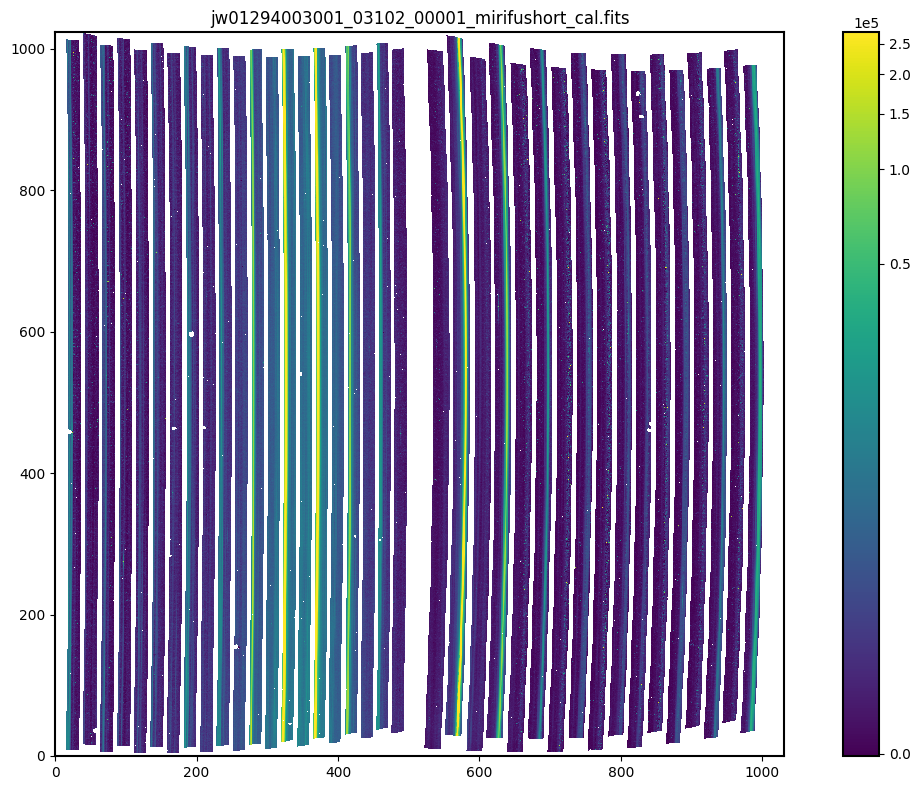

In [12]:
import matplotlib.pyplot as plt
import breads.jwst_tools.plotting

plt.figure(figsize=(12,8))
breads.jwst_tools.plotting.plot_2d_image(cal_files[0])